### Import Libraries

In [12]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import mlflow
import logging
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch import optim
from src.org_unet_parts import *
from dataloader import ACDCDataset
from utils.utils import EarlyStopping
%matplotlib inline

In [13]:
exp_run_id = f'acdc_roi_predictor_img_slices_with_ratios_v4{datetime.now().strftime("%Y%m%d%H%M%S")}'
log_file_name = f'./logs/{exp_run_id}.log'
logging.basicConfig(filename=log_file_name, level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device {device}')
print(f'Using device {device}')

Using device cuda


In [15]:
mlflow.login() # host: https://community.cloud.databricks.com/
mlflow.set_tracking_uri("databricks")

# Initialize logging - create a new MLflow Experiment
mlflow.set_experiment("/cmri-roi-predictor")

2024/11/20 01:49:27 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://community.cloud.databricks.com.


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/624151531129907', creation_time=1732043488953, experiment_id='624151531129907', last_update_time=1732047401090, lifecycle_stage='active', name='/cmri-roi-predictor', tags={'mlflow.experiment.sourceName': '/cmri-roi-predictor',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'chinthalanka.23@cse.mrt.ac.lk',
 'mlflow.ownerId': '8299159887893237'}>

In [16]:
dir_checkpoint = Path('./models/checkpoints/cnn_v1_img_slices_with_ratios_v4/')

epochs = 100
batch_size = 128
lr = 1e-5
scale = 1
amp = False

### Data Loading

In [17]:
root_dir = r'../data/ACDC/img_slices_with_ratios_v4/'
logging.info(f'Using root_dir {root_dir}')

training_dataset = ACDCDataset(root_dir=root_dir, dataset='training', crop_resize_ind=True, margin=0.05)
validation_dataset = ACDCDataset(root_dir=root_dir, dataset='validation', crop_resize_ind=True, margin=0.05)
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing', crop_resize_ind=True, margin=0.05)

logging.info(f'Training dataset size: {len(training_dataset)}')
logging.info(f'Validation dataset size: {len(validation_dataset)}')
logging.info(f'Testing dataset size: {len(testing_dataset)}')

# Load data from the dataset
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

Loaded 16000 training images
Loaded 2000 validation images
Loaded 2000 testing images


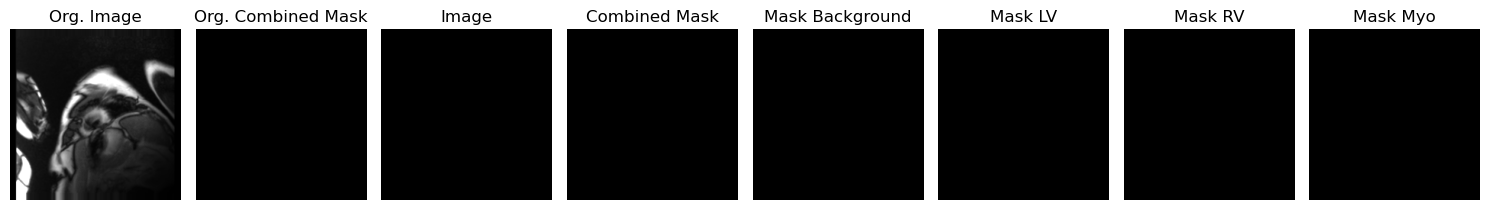

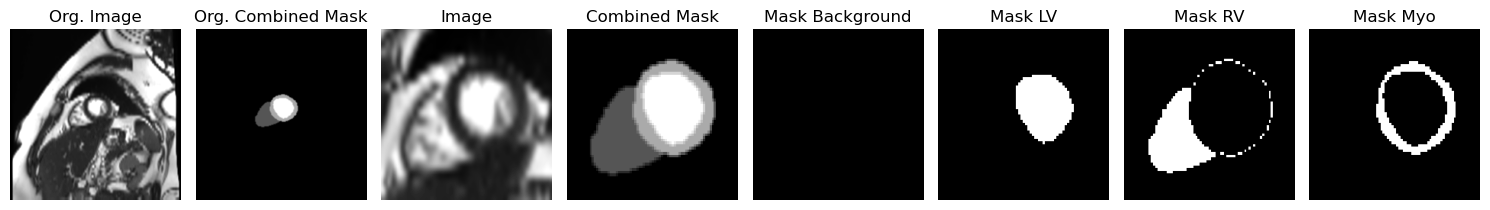

In [18]:
# Iterate through the dataset and plot the first 4 samples
n_samples_to_plot = 2

for i, sample in enumerate(test_dataloader):
    if i >= n_samples_to_plot:
        break

    # Extract data from the sample
    org_image = sample['org_image'][i].squeeze().numpy()
    image = sample['image'][i].squeeze().numpy()
    org_msk_all = sample['org_masks_all'][i].squeeze().numpy()
    msk_all = sample['masks_all'][i].squeeze().numpy()
    msk_bkg = sample['masks'][i][0].squeeze().numpy()
    msk_lv = sample['masks'][i][1].squeeze().numpy()
    msk_rv = sample['masks'][i][2].squeeze().numpy()
    msk_myo = sample['masks'][i][3].squeeze().numpy()

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 8, figsize=(15, 5))

    # Plot the image and masks
    axes[0].imshow(org_image, cmap='gray')
    axes[0].set_title('Org. Image')
    axes[0].axis('off')
    
    axes[1].imshow(org_msk_all, cmap='gray')
    axes[1].set_title('Org. Combined Mask')
    axes[1].axis('off')
    
    axes[2].imshow(image, cmap='gray')
    axes[2].set_title('Image')
    axes[2].axis('off')
    
    axes[3].imshow(msk_all, cmap='gray')
    axes[3].set_title('Combined Mask')
    axes[3].axis('off')
    
    axes[4].imshow(msk_bkg, cmap='gray')
    axes[4].set_title('Mask Background')
    axes[4].axis('off')
    
    axes[5].imshow(msk_lv, cmap='gray')
    axes[5].set_title('Mask LV')
    axes[5].axis('off')
    
    axes[6].imshow(msk_rv, cmap='gray')
    axes[6].set_title('Mask RV')
    axes[6].axis('off')
    
    axes[7].imshow(msk_myo, cmap='gray')
    axes[7].set_title('Mask Myo')
    axes[7].axis('off')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

## ROI Predictor Model

### Simple CNN

In [19]:
class ROIPredictor(nn.Module):
    def __init__(self, n_channels = 1, n_targets = 4):
        super(ROIPredictor, self).__init__()
        self.n_channels = n_channels
        self.n_targets = n_targets  # Predict [x_min, y_min, x_max, y_max]
        
        self.conv = nn.Sequential(
            nn.Conv2d(n_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, n_targets)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

### Model Training

In [20]:
def train_model(
        model,
        device,
        epochs: int = 5,
        start_epoch: int = 1,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
        exp_run_id: str = None,
):
    n_train = len(training_dataset)
    n_val = len(validation_dataset)

    # Start an MLflow run
    with mlflow.start_run() as run:
        # Get the run_id of the current active run
        run_id = run.info.run_id
        
        # Set early stopping parameters
        patience = 5  # Number of epochs to wait for improvement
        min_delta = 0.001  # Minimum change to count as an improvement
        early_stopping = EarlyStopping(patience=patience, min_delta=min_delta)

        logging.info(f'''Starting training:
            Epochs:          {epochs}
            Batch size:      {batch_size}
            Learning rate:   {learning_rate}
            Training size:   {n_train}
            Validation size: {n_val}
            Checkpoints:     {save_checkpoint}
            Device:          {device.type}
            Mixed Precision: {amp}
        ''')

        params = {
            'epochs': epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'training_set_size': n_train,
            'validation_set_size': n_val,
            'mixed_precision': amp
        }

        mlflow.log_params(params)

        # Initialize TensorBoard writer
        writer = SummaryWriter(log_dir=f'./logs/tensorboard_runs/{exp_run_id}')  # This will save logs in '/logs/tensorboard_runs/{exp_run_id}'

        # Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
        # optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=True)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay, foreach=True)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)  # goal: minimize MSE
        grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
        criterion = nn.MSELoss()  # Loss for bounding box regression
        global_step = 0

        # Begin training
        for epoch in range(start_epoch, epochs + 1):
            model.train()
            epoch_loss = 0
            running_val_loss = 0
            running_val_loss_steps = 0

            with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
                for batch in train_dataloader:
                    images, boxes = batch['org_image'], batch['bounding_box']
                    images = images.permute(0, 3, 1, 2)
                    
                    # logging.info(f"images shape: {images.shape}")
                    # logging.info(f"true masks shape: {masks.shape}")

                    assert images.shape[1] == model.n_channels, \
                        f'Network has been defined with {model.n_channels} input channels, ' \
                        f'but loaded images have {images.shape[1]} channels. Please check that ' \
                        'the images are loaded correctly.'

                    images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    true_boxes = boxes.to(device=device, dtype=torch.float32)

                    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                        boxes_pred = model(images)                        
                        loss = criterion(boxes_pred, true_boxes)

                    optimizer.zero_grad(set_to_none=True)
                    grad_scaler.scale(loss).backward()
                    grad_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                    grad_scaler.step(optimizer)
                    grad_scaler.update()

                    pbar.update(images.shape[0])
                    global_step += 1
                    epoch_loss += loss.item()
                    pbar.set_postfix(**{'mse_loss (batch)': loss.item()})

                    # Evaluation round
                    division_step = (n_train // (5 * batch_size))
                    if division_step > 0:
                        if global_step % division_step == 0:
                            model.eval()
                            val_loss = 0.0
                            with torch.no_grad():
                                for val_batch in val_dataloader:
                                    val_images, val_boxes = val_batch['org_image'], val_batch['bounding_box']
                                    val_images = val_images.permute(0, 3, 1, 2)
                                    
                                    val_images = val_images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                                    val_true_boxes = val_boxes.to(device=device, dtype=torch.float32)
                                    
                                    val_predictions = model(val_images)
                                    val_loss = criterion(val_predictions, val_true_boxes)
                                    val_loss += val_loss.item()
                            avg_val_loss = val_loss / len(val_dataloader)
                            running_val_loss += avg_val_loss
                            running_val_loss_steps += 1
                            scheduler.step(avg_val_loss)
                            logging.info(f'Validation MSE Loss: {avg_val_loss:.4f}')
                            model.train()

            if save_checkpoint:
                Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
                state_dict = model.state_dict()
                # state_dict['mask_values'] = training_dataset.mask_values
                torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
                logging.info(f'Checkpoint {epoch} saved!')

            # Log metrics to TensorBoard
            avg_loss = epoch_loss / len(train_dataloader)
            avg_dice_val_loss = running_val_loss / running_val_loss_steps
            writer.add_scalar("Training MSE Loss", avg_loss, epoch)   
            
            # Check for early stopping
            early_stopping(avg_dice_val_loss)
            logging.info(f"Validation Dice Loss at Epoch {epoch}: {avg_dice_val_loss:.4f}")
            if early_stopping.early_stop:
                print(f"Early stopping triggered at epoch {epoch+1}")
                logging.info(f'Early stopping triggered at epoch {epoch+1}')
                break

        # Flush and close the writer when done
        writer.flush()
        writer.close()

    return run_id

### Training

In [21]:
# Weight Initialization
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [22]:
model = ROIPredictor(n_channels=1, n_targets=4)

# Use checkpoints to train
use_checkpoints = False

if use_checkpoints:
    checkpoint_epoch = 1
    checkpoint_path = str(dir_checkpoint / f'checkpoint_epoch{checkpoint_epoch}.pth')
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint)
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint_epoch + 1
else:
    start_epoch = 1
    model.apply(weights_init)

model = model.to(memory_format=torch.channels_last)

logging.info(f'Network:\n'
             f'\t{model.n_channels} input channels\n'
             f'\t{model.n_targets} output variables\n'
            )

model.to(device=device)

try:
    run_id = train_model(
        model=model,
        epochs=epochs,
        start_epoch=start_epoch,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp,
        exp_run_id=exp_run_id
    )
except torch.cuda.OutOfMemoryError:
    logging.error('Detected OutOfMemoryError! '
                  'Enabling checkpointing to reduce memory usage, but this slows down training. '
                  'Consider enabling AMP (--amp) for fast and memory efficient training')
    torch.cuda.empty_cache()
    model.use_checkpointing()
    run_id = train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp,
        exp_run_id=exp_run_id
    )

Epoch 1/100:  74%|███████▎  | 11776/16000 [16:35<05:56, 11.83img/s, mse_loss (batch)=0.00912]


KeyboardInterrupt: 

### Testing and Evaluation

In [ ]:
'''
# Model Evaluation Using a Checkpoint
model = FeedbackResUNet(input_channels=1, num_classes=4)

# Load the state dict from the checkpoint
checkpoint_dir = Path('./models/checkpoints/feedback_resunet_img_slices_with_ratios_v4/')
checkpoint = torch.load(str(checkpoint_dir / 'checkpoint_epoch{}.pth'.format('5')))
model.load_state_dict(checkpoint)
model = model.to(device)
'''

In [ ]:
def visualize_prediction(model, dataloader, device, sample_idx=0, img_idx=0, n_classes=4, combined_mask=True):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            if i == sample_idx:
                # Extract data from the sample
                images = sample['image']
                true_masks = sample['masks']
                true_masks_all = sample['masks_all']
                print(f'images shape: {images.shape}')
                print(f'true masks shape: {true_masks.shape}')
                print(f'combined true masks shape: {true_masks_all.shape}')
                images = images.permute(0, 3, 1, 2)
                true_masks_all = true_masks_all.permute(0, 3, 1, 2)

                images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks = true_masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks_all = true_masks_all.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                # true_masks = (true_masks * 255).round().long()
                true_masks_all = (true_masks_all * 255).round().long()

                outputs = model(images)

                # Apply sigmoid to convert logits to probabilities, then threshold
                # preds = torch.sigmoid(outputs)
                preds = (outputs > 0.5).float()  # Convert to binary masks (0 or 1)
                # preds = preds.float().cpu().numpy().squeeze(1)

                # Convert logits to predicted class labels
                # preds = torch.argmax(outputs, dim=1).long()

                image = images[img_idx].cpu().squeeze()
                true_mask_all = true_masks_all[img_idx].cpu().squeeze().numpy()
                true_mask_bkg = true_masks[img_idx][0].cpu().squeeze().numpy()
                true_mask_lv = true_masks[img_idx][1].cpu().squeeze().numpy()
                true_mask_rv = true_masks[img_idx][2].cpu().squeeze().numpy()
                true_mask_myo = true_masks[img_idx][3].cpu().squeeze().numpy()

                # Apply argmax to get the class with the highest probability for each pixel
                pred_mask_all = None
                # pred_mask_all = torch.argmax(preds[img_idx], dim=0).cpu().numpy()  # Shape: (height, width)
                # pred_mask_all = preds[img_idx].cpu().numpy()

                print(f'preds shape: {preds.shape}')
                print(f'True mask unique values: {np.unique(true_mask_all)}')
                # print(f'Pred mask unique values: {np.unique(pred_mask_all)}')

                if n_classes > 1 and combined_mask:
                    fig, ax = plt.subplots(1, 6, figsize=(16, 5))
                    ax[0].imshow(image, cmap='gray')
                    ax[0].set_title('Input Image')

                    ax[1].imshow(true_mask_lv, cmap='gray')
                    ax[1].set_title('True LV')

                    ax[2].imshow(true_mask_rv, cmap='gray')
                    ax[2].set_title('True RV')

                    ax[3].imshow(true_mask_myo, cmap='gray')
                    ax[3].set_title('True MYO')

                    ax[4].imshow(true_mask_all, cmap='gray')
                    ax[4].set_title('True Mask')

                    ax[5].imshow(pred_mask_all, cmap='gray')
                    ax[5].set_title('Predicted Mask')
                elif n_classes > 1 and not combined_mask:
                    fig, ax = plt.subplots(2, 5, figsize=(15, 8))
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')

                    ax[0][1].imshow(true_mask_bkg, cmap='gray')
                    ax[0][1].set_title('True Background')

                    ax[0][2].imshow(true_mask_lv, cmap='gray')
                    ax[0][2].set_title('True LV')

                    ax[0][3].imshow(true_mask_rv, cmap='gray')
                    ax[0][3].set_title('True RV')

                    ax[0][4].imshow(true_mask_myo, cmap='gray')
                    ax[0][4].set_title('True MYO')

                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')

                    ax[1][1].imshow(preds[img_idx][0].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][1].set_title('Pred Background')

                    ax[1][2].imshow(preds[img_idx][1].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][2].set_title('Pred LV')

                    ax[1][3].imshow(preds[img_idx][2].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][3].set_title('Pred RV')

                    ax[1][4].imshow(preds[img_idx][3].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][4].set_title('Pred MYO')
                else:
                    print(f'Image: {torch.unique(images[img_idx])}')
                    print(f'True Mask: {torch.unique(true_masks_all[img_idx])}')
                    print(f'Pred Mask: {np.unique(preds[img_idx])}')

                    fig, ax = plt.subplots(2, 2, figsize=(8, 8))
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')

                    ax[0][1].imshow(true_mask_all, cmap='gray')
                    ax[0][1].set_title('True Mask')

                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')

                    ax[1][1].imshow(pred_mask_all, cmap='gray')
                    ax[1][1].set_title('Predicted Mask')

                plt.show()
                break  # Visualize only one image
            else:
                continue

In [ ]:
visualize_prediction(model, test_dataloader, device, sample_idx=1, img_idx = 3, n_classes=4, combined_mask=False)

In [ ]:
# torch.cuda.empty_cache()

### Model Evaluation

In [ ]:
# Function to calculate Dice score for a single class
def dice_score(pred, target, smooth=1e-6):
    intersection = (pred * target).sum()
    sets_sum = pred.sum() + target.sum()
    sets_sum = torch.where(sets_sum == 0, intersection, sets_sum)
    dice = (2. * intersection + smooth) / (sets_sum + smooth)
    return dice


# Function to evaluate Dice score for each class in the test set
def evaluate_dice_score(model, dataloader, num_classes=4, device='cpu', threshold=0.5):
    model.eval()  # Set model to evaluation mode
    dice_scores = [0.0] * num_classes  # List to store Dice score for each class
    # count = 0  # Number of samples
    batch_count = len(dataloader) # Number of batches

    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            # Extract data from the sample
            images = sample['image']
            true_masks = sample['masks']
            true_masks_all = sample['masks_all']
            # print(f'images shape: {images.shape}')
            # print(f'true masks shape: {true_masks.shape}')
            # print(f'combined true masks shape: {true_masks_all.shape}')
            images = images.permute(0, 3, 1, 2)
            true_masks_all = true_masks_all.permute(0, 3, 1, 2)

            images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            true_masks = true_masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)

            outputs = model(images)  # Shape: (batch_size, 4, height, width)
            # outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities

            # Binarize outputs based on threshold
            # predictions = (outputs > threshold).float()  # Shape: (batch_size, 4, height, width)
            predictions = (F.sigmoid(outputs) > threshold).float()

            # Calculate Dice score for each class
            for i in range(num_classes):  # Loop over each class
                dice_scores[i] += dice_coeff(
                    predictions[:, i, :, :].flatten(0, 1),
                    true_masks[:, i, :, :].flatten(0, 1),
                    reduce_batch_first=False
                    )
                '''
                dice_scores[i] += dice_score(
                    predictions[:, i, :, :],
                    true_masks[:, i, :, :]
                    )
                '''

            # count += images.size(0)  # Update sample count
            # batch_count += 1 # Update batch count

    # Average Dice scores across the dataset
    # avg_dice_scores = [score / count for score in dice_scores]
    avg_dice_scores_batch = [score / batch_count for score in dice_scores]
    return avg_dice_scores_batch

In [ ]:
# run_id = "74fa318220bd4e988b801717b3e193e2"

with mlflow.start_run(run_id=run_id):
    # Compute the Dice score for each class in the Train set
    avg_dice_scores_batch = evaluate_dice_score(model, train_dataloader, device=device)
    print("Dice Scores - Train Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("train_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("train_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("train_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("train_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("train_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))


    # Compute the Dice score for each class in the Validation set
    avg_dice_scores_batch = evaluate_dice_score(model, val_dataloader, device=device)
    print("\nDice Scores - Validation Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("val_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("val_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("val_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("val_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("val_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))


    # Compute the Dice score for each class in the Test set
    avg_dice_scores_batch = evaluate_dice_score(model, test_dataloader, device=device)
    print("\nDice Scores - Test Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4)}")
    mlflow.log_metric("test_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("test_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("test_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("test_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("test_dice_score", round(torch.tensor(avg_dice_scores_batch[1:]).mean().item(), 4))